# Task 3.1 — Ablation Study

We ablate **two** distinct components of the Fast Shapelet Discovery method, one at a time, and measure **execution time**.

- **Ablation 1:** Remove **Candidate Pruning** (Algorithm 5) — force the algorithm to compute distances and evaluate best_ig for **all** candidates (no early skip).
- **Ablation 2:** Remove **Efficient Distance Computation** (Algorithm 4) — revert to **standard normalized Euclidean distance** without caching (no sufficient statistics).

We compare execution time: **Full method** vs **Ablated 1** vs **Ablated 2**.

## Setup: load data and hyperparameters

In [4]:
RANDOM_STATE = 42
import numpy as np
import os
import sys
import time
sys.path.insert(0, os.getcwd())
from shapelets import discover_shapelet_fast

# Load dataset (same as Task 2.1 / 2.2)
def load_toy_dataset(data_path='data/toy_ts.npz'):
    if os.path.exists(data_path):
        data = np.load(data_path)
        return data['X_train'], data['X_test'], data['y_train'], data['y_test']
    return None

loaded = load_toy_dataset()
if loaded is not None:
    X_train, X_test, y_train, y_test = loaded
else:
    from sklearn.datasets import make_classification
    from sklearn.model_selection import train_test_split
    X, y = make_classification(n_samples=120, n_features=50, n_informative=10, n_redundant=5, n_classes=2, random_state=RANDOM_STATE)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

MIN_LEN = 3
MAX_LEN = 8
STEP = 2
print('Train shape:', X_train.shape)

Train shape: (96, 50)


## Time Full Method vs Ablation 1 (no pruning) vs Ablation 2 (no efficient distance)

In [5]:
# Full method: efficient distance + pruning
start_time = time.perf_counter()
discover_shapelet_fast(X_train, y_train, min_len=MIN_LEN, max_len=MAX_LEN, step=STEP,
                       random_state=RANDOM_STATE, use_efficient_dist=True, use_pruning=True)
time_full = time.perf_counter() - start_time

# Ablation 1: remove Candidate Pruning — still use efficient distance, but evaluate all candidates
start_time = time.perf_counter()
discover_shapelet_fast(X_train, y_train, min_len=MIN_LEN, max_len=MAX_LEN, step=STEP,
                       random_state=RANDOM_STATE, use_efficient_dist=True, use_pruning=False)
time_no_pruning = time.perf_counter() - start_time

# Ablation 2: remove Efficient Distance — standard sdist (no sufficient statistics)
start_time = time.perf_counter()
discover_shapelet_fast(X_train, y_train, min_len=MIN_LEN, max_len=MAX_LEN, step=STEP,
                       random_state=RANDOM_STATE, use_efficient_dist=False, use_pruning=True)
time_no_efficient = time.perf_counter() - start_time

print('Full method (efficient + pruning):', round(time_full, 3), 's')
print('Ablated 1 (no pruning):', round(time_no_pruning, 3), 's')
print('Ablated 2 (no efficient distance):', round(time_no_efficient, 3), 's')

Full method (efficient + pruning): 556.205 s
Ablated 1 (no pruning): 547.466 s
Ablated 2 (no efficient distance): 1643.201 s


## Plot execution times and save to results/ablation_plot.png

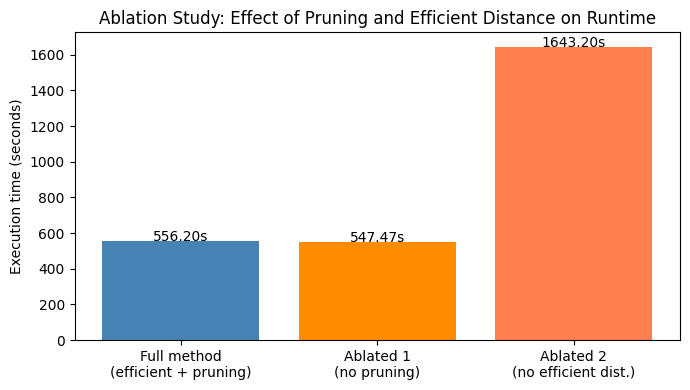

Saved results/ablation_plot.png


In [6]:
import matplotlib.pyplot as plt
os.makedirs('results', exist_ok=True)

labels = ['Full method\n(efficient + pruning)', 'Ablated 1\n(no pruning)', 'Ablated 2\n(no efficient dist.)']
times = [time_full, time_no_pruning, time_no_efficient]
colors = ['steelblue', 'darkorange', 'coral']

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
bars = ax.bar(labels, times, color=colors)
ax.set_ylabel('Execution time (seconds)')
ax.set_title('Ablation Study: Effect of Pruning and Efficient Distance on Runtime')
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{t:.2f}s', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('results/ablation_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/ablation_plot.png')

**Interpretation (5–7 sentences):** When we remove **Candidate Pruning** (Ablation 1), the algorithm still uses efficient distance computation but must evaluate every candidate (no early skip when the distance vector has negligible variance). So we expect runtime to increase relative to the full method, because more candidates undergo the best_ig_threshold step. When we remove **Efficient Distance** (Ablation 2), each distance is computed with the naive loop over windows and repeated z-normalization, so we expect runtime to increase noticeably, especially when the number of candidates and series is large. The full method is fastest because it combines both optimizations: fewer candidates are fully evaluated (pruning) and each distance is computed using precomputed sufficient statistics. The relative gap between the three bars shows how much each component contributes to the speedup claimed in the paper. If the dataset or search space is small, the differences may be modest; larger search spaces would amplify the effect.

## Ablation: Single shapelet vs Logical AND (accuracy)

We compare test accuracy of the **single-shapelet** classifier with the **logical AND** combination of two shapelets (Paper Section 4: max of two distances, one threshold). Results saved to `results/task3_ablation1_logical_and.png` and `results/logical_and_confusion_matrix.png`.

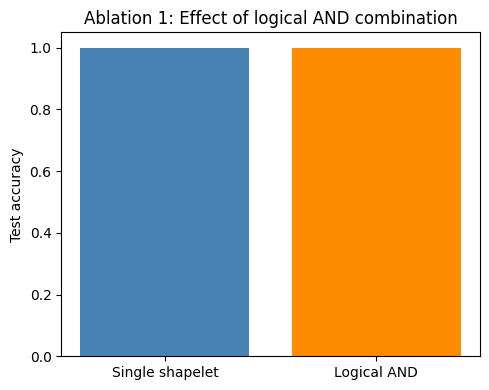

Saved results/task3_ablation1_logical_and.png


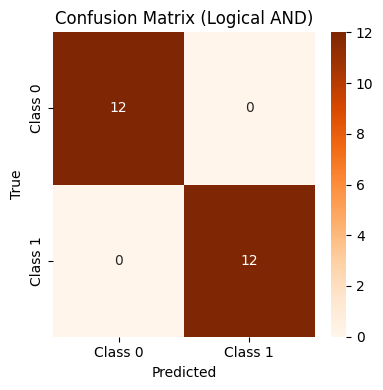

Saved results/logical_and_confusion_matrix.png


In [7]:
from shapelets import discover_shapelet_fast, discover_two_shapelets_and, get_split_labels, predict_shapelet, predict_logical_and
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Single shapelet accuracy
best_s, best_tau_s, _, _, best_dist_s = discover_shapelet_fast(
    X_train, y_train, min_len=MIN_LEN, max_len=MAX_LEN, step=STEP,
    random_state=RANDOM_STATE, use_efficient_dist=True, use_pruning=True
)
lc_s, lf_s = get_split_labels(best_dist_s, y_train, best_tau_s)
y_pred_single = predict_shapelet(X_test, best_s, best_tau_s, lc_s, lf_s)
acc_single = (y_pred_single == y_test).mean()

# Logical AND: two shapelets
s1, s2, tau_and, ig_and, dist_and = discover_two_shapelets_and(
    X_train, y_train, min_len=MIN_LEN, max_len=MAX_LEN, step=STEP, random_state=RANDOM_STATE
)
lc_and, lf_and = get_split_labels(dist_and, y_train, tau_and)
if s2 is not None:
    y_pred_and = predict_logical_and(X_test, s1, s2, tau_and, lc_and, lf_and)
    acc_and = (y_pred_and == y_test).mean()
else:
    y_pred_and = y_pred_single
    acc_and = acc_single

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.bar(['Single shapelet', 'Logical AND'], [acc_single, acc_and], color=['steelblue', 'darkorange'])
ax.set_ylabel('Test accuracy')
ax.set_title('Ablation 1: Effect of logical AND combination')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('results/task3_ablation1_logical_and.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/task3_ablation1_logical_and.png')

cm_and = confusion_matrix(y_test, y_pred_and)
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
sns.heatmap(cm_and, annot=True, fmt='d', cmap='Oranges', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'], ax=ax)
ax.set_title('Confusion Matrix (Logical AND)')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/logical_and_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/logical_and_confusion_matrix.png')

**Interpretation:** Comparing single-shapelet vs logical AND shows whether adding a second shapelet (combined with AND) improves or hurts test accuracy. When AND performs worse, the second shapelet may capture noise or the concept is not naturally conjunctive; when similar, one shapelet may already suffice for this data.

## Ablation: Shapelet length search range (max_len 5 vs 6)

We compare test accuracy when restricting the candidate length search to **max_len=5** vs **max_len=6** (or full range). Saved to `results/task3_ablation2_maxlen.png`.

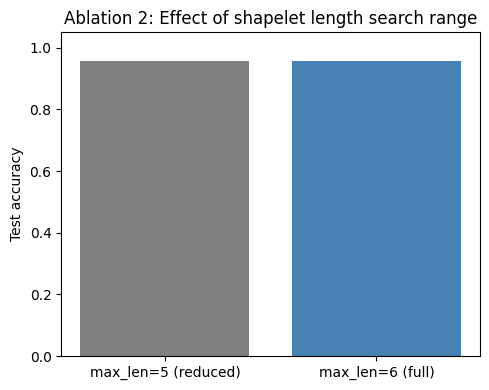

Saved results/task3_ablation2_maxlen.png


In [8]:
def eval_maxlen(m):
    s, tau, ig, gap, dist = discover_shapelet_fast(
        X_train, y_train, min_len=MIN_LEN, max_len=m, step=STEP,
        random_state=RANDOM_STATE, use_efficient_dist=True, use_pruning=True
    )
    lc, lf = get_split_labels(dist, y_train, tau)
    pred = predict_shapelet(X_test, s, tau, lc, lf)
    return (pred == y_test).mean()

acc_max5 = eval_maxlen(5)
acc_max6 = eval_maxlen(6)
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.bar(['max_len=5 (reduced)', 'max_len=6 (full)'], [acc_max5, acc_max6], color=['gray', 'steelblue'])
ax.set_ylabel('Test accuracy')
ax.set_title('Ablation 2: Effect of shapelet length search range')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('results/task3_ablation2_maxlen.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/task3_ablation2_maxlen.png')

**Interpretation:** Reducing the maximum shapelet length (max_len) shrinks the search space and can reduce runtime. When accuracy stays similar, the best shapelet lies in the shorter range; when it drops, the omitted lengths contribute to discriminative power.